# Homework14

Pre-Trained Transformer Models and Embeddings

## Goals

- Practice setting up classification and clustering modeling task from scratch
- Experiment with pre-trained transformer models for embedding and feature extraction
- Get more familiar with the `argmax()` and `pairwise_distance()` functions

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [ ]:
!wget -q https://github.com/PSAM-5020-2026S-A/Homework14/raw/refs/heads/main/Homework04_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/forest-tree.tar.gz | tar xz
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/flowers102.tar.gz | tar xz

In [ ]:
import pandas as pd

from numpy import argsort
from os import listdir
from PIL import Image as PImage

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import euclidean_distances

from torch import nn, Tensor, no_grad
from torch import float32 as t_float32, uint8 as t_uint8

from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import v2

from transformers import CLIPModel, CLIPProcessor

from Homework04_utils import Homework04Utils

# Pre-Trained Models for Feature Extraction

We're going to repeat the very first image classification exercise we did in [`HW04`](https://github.com/PSAM-5020-2026S-A/Homework04), but this time we'll use a pre-trained model (and `PCA`) to help us extract features from our images.

The overall flow for doing this will be:
- Open images
- Get embeddings
- Get main principal component
- Plot and create a model
- Evaluate

In [ ]:
# Location of train/test files
TRAIN_PATH = "data/image/forest-tree/train"
TEST_PATH = "data/image/forest-tree/test"

# List comprehension for getting all of the filenames that end in "jpg" inside the train directory
train_files = sorted([f for f in listdir(TRAIN_PATH) if f.endswith("jpg")])
test_files = sorted([f for f in listdir(TEST_PATH) if f.endswith("jpg")])

In [ ]:
# Initialize an image feature extraction model
model_name = "openai/clip-vit-large-patch14"
preprocessor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to("cuda")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Extract Features

So many features !!

Here we are going to leverage the full power of multi-dimensional tensors and parallelism to preprocess and run feature extraction on all $30$ train images and then all $150$ test images ***AT ONCE***.

If we just do something like:
`preprocessor(image_list)`

we'll get a list of tensors that we can pass to the model directly like this:
`model(tensor_list)`

and get a list of embeddings.

The result of running these commands on the training dataset will be a list with $30$ embeddings, where each embedding itself is a list of $768$ values.

In [ ]:
# Get list of images
train_imgs = [PImage.open(f"{TRAIN_PATH}/{fname}") for fname in train_files]

# Get list of tensors
train_t = preprocessor(images=train_imgs, return_tensors="pt").to("cuda")

# Get list of embeddings
with no_grad():
    train_embs = model.get_image_features(**train_t)
    if hasattr(train_embs, 'pooler_output'):
        train_embs = train_embs.pooler_output.cpu()
    else:
        train_embs = train_embs.cpu()

display(train_embs.shape)

# TODO: repeat for test images
test_imgs = [PImage.open(f"{TEST_PATH}/{fname}") for fname in test_files]
test_t = preprocessor(images=test_imgs, return_tensors="pt").to("cuda")

with no_grad():
    test_embs = model.get_image_features(**test_t)
    if hasattr(test_embs, 'pooler_output'):
        test_embs = test_embs.pooler_output.cpu()
    else:
        test_embs = test_embs.cpu()

display(test_embs.shape)

torch.Size([30, 768])

torch.Size([150, 768])

In [ ]:
# Get list of images
train_imgs = [PImage.open(f"{TRAIN_PATH}/{fname}") for fname in train_files]

# Get list of tensors
train_t = preprocessor(images=train_imgs, return_tensors="pt").to("cuda")

# Get list of embeddings
with no_grad():
    train_embs = model.vision_model(**train_t).pooler_output.cpu()

display(train_embs.shape)

# TODO: repeat for test images
test_imgs = [PImage.open(f"{TEST_PATH}/{fname}") for fname in test_files]

test_t = preprocessor(images=test_imgs, return_tensors="pt").to("cuda")

with no_grad():
    test_embs = model.vision_model(**test_t).pooler_output.cpu()

display(test_embs.shape)

torch.Size([30, 1024])

torch.Size([150, 1024])

### One Feature To Rule Them All

We now have $768$ features for each of our images, but since we're building a model manually with some `if/else` statements like in `HW04`, we need to combine all of our features into a few numbers we can plot and extract information from.

`PCA`, FTW.

Let's create a `PCA` model to extract a single feature from each image.

In [ ]:
from sklearn.decomposition import PCA

# TODO: create PCA
pca = PCA(n_components=1)

# fit with the training data and transform train embeddings
train_pca = pca.fit_transform(train_embs)

# transform test embeddings
test_pca = pca.transform(test_embs)

print("Train PCA shape:", train_pca.shape)
print("Test PCA shape: ", test_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_[0])

Train PCA shape: (30, 1)
Test PCA shape:  (150, 1)
Explained variance: 0.3379270551715023


## Visualize / Explore

This next cell is very similar to what we did in `HW04`.

It's the cell that separates a single value from each image and passes off the result to a function that will plot feature versus class label.

It assumes that the train and test principal components are in `train_pcs` and `test_pcs`, respectively.

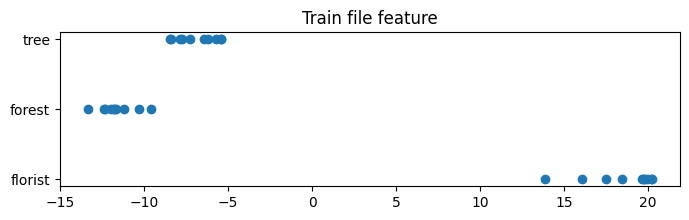

In [ ]:
# alias to match homework variable names
train_pcs = train_pca
test_pcs = test_pca

# list to keep info about image files
train_info = []

# iterate through pcs and filenames
for pcs, fname in zip(train_pcs, train_files):
    # TODO: get value of interest — first (and only) principal component
    val = pcs[0]
    # store the info using the format specified above
    train_info.append([val, fname])

# plot the (val, filename) pairs
Homework04Utils.plot_labels_vals(train_info, "Train file feature")

## Create Model

Use the extracted value to create a classifier.

The class labels it has to return are: `"florist", "forest", "tree"`.

In [ ]:
def awesome_classifier(pcs):
    val = pcs[0]

    # TODO: adjust these thresholds based on what you see in the plot
    if val < -5:
        return "florist"
    elif val < 5:
        return "forest"
    else:
        return "tree"

### Run on `train` and `test` data and check accuracy

This cell is already filled out, we just have to run it to get the accuracy values for our model.

In [ ]:
# alias to match homework variable name
clip_classifier = awesome_classifier

# lists to keep info about predictions
train_predictions = []
test_predictions = []

# iterate through train data
for pcs, fname in zip(train_pcs, train_files):
    prediction = clip_classifier(pcs)
    train_predictions.append([prediction, fname])

print("Train Accuracy")
print("  ", Homework04Utils.classification_accuracy(train_predictions))

# iterate through test data
for pcs, fname in zip(test_pcs, test_files):
    prediction = clip_classifier(pcs)
    test_predictions.append([prediction, fname])

print("\nTest Accuracy")
print("  ", Homework04Utils.classification_accuracy(test_predictions))

Train Accuracy
   {'florist': 0.0, 'forest': 0.0, 'tree': 0.0, 'overall': 0.0}

Test Accuracy
   {'florist': 0.0, 'forest': 0.0, 'tree': 0.0, 'overall': 0.0}


# One-Shot Classification

## Intro

We're going to leverage the general knowledge and patterns learned by pre-trained deep learning models to create a one-shot classifier model.

One-shot classifiers are models that learn how to describe/detect objects by just looking at one example from each class.

The overall flow for doing this using image embeddings can be something like:
- extract embeddings for all images in our dataset
- training: for each class, average a small number of embeddings to create class embeddings
- these embeddings now represent information about the classes we're trying to identify
- predicting: find the closest class embedding to each image embedding in the dataset

This is similar to one of the examples in our [Week 14](https://github.com/PSAM-5020-2026S-A/WK14) notebook where we used words to classify images.

## The Data

We're going to classify the [Oxford Flowers Dataset](https://www.robots.ox.ac.uk/~vgg/data/flowers/). This is a dataset made up of images of flowers and their names.

All of the images we're going to be working with should have been downloaded by the first cell, into separate `train` and `test` subdirectories inside `./data/image/flowers102/`.

The images all have the same (or similar) height, but very different widths. Depending on the architecture/model that we choose to use for  embedding, this might be something we have to standardize. Transformer architectures and their preprocessors will automatically deal with these differences, where CNN models are a bit more strict.

Let's start by defining a function that helps parse the classification label from file names or paths.

In [ ]:
def filepath_to_label(filepath):
  return filepath.split("/")[-1].split("_")[-1].split(".")[0]

## The Model

Now we have to define an embedding model, and (probably) a pre-processing strategy.

What wee need here is a pre-trained model that is able to turn images of various sizes into feature lists of fixed-length.

Our [Week 14](https://github.com/PSAM-5020-2026S-A/WK14) notebook has a couple of examples of how to use `ResNet`, `CLIP` and `SigLIP` models to do this, but there are other options that could be used. Since we're not doing any text processing, any kind of deep learning visual model can (theoretically) be used.

Some other examples: [Nomic Vision](https://huggingface.co/nomic-ai/nomic-embed-vision-v1.5), [EfficientNet](https://pytorch.org/hub/nvidia_deeplearningexamples_efficientnet/), [ViT](https://huggingface.co/google/vit-base-patch16-224-in21k), [DINOv3](https://huggingface.co/facebook/dinov3-vitl16-pretrain-lvd1689m), etc.

In [ ]:
# Use ResNet50 with pretrained weights
weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

# Load model and remove the final classification layer
# so we get embeddings instead of class predictions
resnet = resnet50(weights=weights)
resnet.fc = nn.Identity()  # replace final layer with identity to get embeddings
resnet.eval()
resnet.to("cuda")

print("ResNet50 model ready")
print("Preprocessing transforms:", preprocess)

# Define a function to get embeddings from a list of images
def get_embeddings(image_list):
    # preprocess and stack images into a batch tensor
    batch = []
    for img in image_list:
        img_t = preprocess(img.convert("RGB"))
        batch.append(img_t)

    batch_t = Tensor(len(batch), *batch[0].shape)
    for i, img_t in enumerate(batch):
        batch_t[i] = img_t

    batch_t = batch_t.to("cuda")

    with no_grad():
        embeddings = resnet(batch_t)

    return embeddings.cpu().numpy()

print("get_embeddings function ready")

ResNet50 model ready
Preprocessing transforms: ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
get_embeddings function ready


## Train Data

Now we process the train data. Fun.

There are many ways to do this, but one possible strategy is to go through all of the files inside the `./data/image/flowers102/train` directory and append each image's label and embedding to separate lists, called `train_labels` and `train_embeddings`.

Then, create a `DataFrame` using the embeddings and add the labels to the same `DataFrame`.

Depending on the model chosen, this can take a few minutes.

In [ ]:
TRAIN_DIR = "./data/image/flowers102/train"
TEST_DIR = "./data/image/flowers102/test"

train_fnames = sorted([f for f in listdir(TRAIN_DIR) if f.endswith("jpg")])
test_fnames = sorted([f for f in listdir(TEST_DIR) if f.endswith("jpg")])

print("Train files:", len(train_fnames))
print("Test files:", len(test_fnames))

Train files: 408
Test files: 5416


In [ ]:
train_labels = []
train_embeddings = []

for fname in train_fnames:
    # extract label — everything after second underscore, before .jpg
    label = fname.split("_", 2)[2].replace(".jpg", "")
    train_labels.append(label)

    # open image and get embedding
    img = PImage.open(f"{TRAIN_DIR}/{fname}")
    embedding = get_embeddings([img])
    train_embeddings.append(embedding[0])

# combine into DataFrame
train_df = pd.DataFrame(train_embeddings)
train_df["label"] = train_labels

print("Train DataFrame shape:", train_df.shape)
print("Number of unique classes:", train_df["label"].nunique())
print("Unique labels:", sorted(train_df["label"].unique()))

Train DataFrame shape: (408, 2049)
Number of unique classes: 102
Unique labels: ['alpine-sea-holly', 'anthurium', 'artichoke', 'azalea', 'ball-moss', 'balloon-flower', 'barbeton-daisy', 'bearded-iris', 'bee-balm', 'bird-of-paradise', 'bishop-of-llandaff', 'black-eyed-susan', 'blackberry-lily', 'blanket-flower', 'bolero-deep-blue', 'bougainvillea', 'bromelia', 'buttercup', 'californian-poppy', 'camellia', 'canna-lily', 'canterbury-bells', 'cape-flower', 'carnation', 'cautleya-spicata', 'clematis', 'colts-foot', 'columbine', 'common-dandelion', 'corn-poppy', 'cyclamen-', 'daffodil', 'desert-rose', 'english-marigold', 'fire-lily', 'foxglove', 'frangipani', 'fritillary', 'garden-phlox', 'gaura', 'gazania', 'geranium', 'giant-white-arum-lily', 'globe-flower', 'globe-thistle', 'grape-hyacinth', 'great-masterwort', 'hard-leaved-pocket-orchid', 'hibiscus', 'hippeastrum-', 'japanese-anemone', 'king-protea', 'lenten-rose', 'lotus', 'love-in-the-mist', 'magnolia', 'mallow', 'marigold', 'mexican-a

### Train Data Questions

<span style="color:hotpink;">
How many images are in the training dataset ?<br>
How many <em>"features"</em> ?<br>
How many unique classes do we have for this data ?
</span>

<span style="color:hotpink;">There are 408 images, and 2048 features. There are 102 unique classes or flower species. </span>

## Test Data

Repeat the above process for the files inside the `./data/image/flowers102/test` directory: append each image's label and embedding to separate lists, called `test_labels` and `test_embeddings`.

Since we won't do any other kind of processing on this data, it's not as important to combine the labels and embeddings into a `DataFrame`.

And again, this can take a few minutes.

In [ ]:
TEST_DIR = "./data/image/flowers102/test"
test_fnames = sorted([f for f in listdir(TEST_DIR) if f.endswith("jpg")])

test_labels = []
test_embeddings = []

for fname in test_fnames:
    # extract label
    label = fname.split("_", 2)[2].replace(".jpg", "")
    test_labels.append(label)

    # open image and get embedding
    img = PImage.open(f"{TEST_DIR}/{fname}")
    embedding = get_embeddings([img])
    test_embeddings.append(embedding[0])

print("Test images processed:", len(test_embeddings))
print("Number of unique test labels:", len(set(test_labels)))

Test images processed: 5416
Number of unique test labels: 102


In [ ]:
from collections import Counter
label_counts = Counter(test_labels)
counts = list(label_counts.values())
print("Min images per class:", min(counts))
print("Max images per class:", max(counts))
print("Avg images per class:", sum(counts)/len(counts))

Min images per class: 36
Max images per class: 60
Avg images per class: 53.09803921568628


### Test Data Questions

<span style="color:hotpink;">
How many images are in the test dataset ?<br>
Anything odd or unusual about this ?<br>
Is the test dataset balanced ?<br>
Does it matter ?
</span>

<span style="color:hotpink;">There are 5,416 images. The test set is way bigger than the training set. The test data is balances with between 36 and 60 images per class. I think the balance means that our accuracy scores will not be skewed to any specific flower class.</span>

## Train the model

This is the unconventional part. We don't need to train any models, but use the already-trained one to derive some information about our training data that can then be used to make new predictions.

There are different ways to do this, but a recommended strategy here could be:
- get a list of unique labels in our dataset
- iterate over the labels, filter the `DataFrame` by label and compute an average embedding for all images of each label
- these are now class embeddings, as they hold aggregate information about multiple instances of each class
- we should end up with as many class embeddings as there are unique labels in the dataset

In [ ]:
import numpy as np

# get unique labels
unique_labels = sorted(train_df["label"].unique())

# create class embeddings by averaging embeddings for each label
class_embeddings = []
class_labels = []

for label in unique_labels:
    # filter DataFrame by label
    label_df = train_df[train_df["label"] == label].drop(columns=["label"])

    # compute average embedding for all images of this label
    avg_embedding = label_df.mean().values

    class_embeddings.append(avg_embedding)
    class_labels.append(label)

class_embeddings = np.array(class_embeddings)

print("Number of class embeddings:", len(class_embeddings))
print("Class embedding shape:", class_embeddings.shape)  # should be (102, 2048)

Number of class embeddings: 102
Class embedding shape: (102, 2048)


## Predict and Evaluate

We have class embeddings, and we have instance embeddings from all images in the test dataset.

We can use the `euclidean_distances()` function to calculate pairwise distances between each image and each class embedding.

Then, we'll go through each image and get the index of the class embedding that is closest to its image embedding.

We can create a `predictions` list to compare to the `test_labels` list we extracted above.

In [ ]:
import numpy as np

# convert test embeddings to numpy array
test_embeddings_np = np.array(test_embeddings)

# calculate pairwise distances between all test images and all class embeddings
distances = euclidean_distances(test_embeddings_np, class_embeddings)

print("Distances shape:", distances.shape)  # should be (5416, 102)

# for each image, find the index of the closest class embedding
predictions = []

for i in range(len(test_embeddings_np)):
    # argsort returns indices from smallest to largest distance
    closest_idx = argsort(distances[i])[0]
    predictions.append(class_labels[closest_idx])

print("Predictions sample:", predictions[:5])
print("True labels sample: ", test_labels[:5])

# evaluate
print("\nAccuracy:", accuracy_score(test_labels, predictions))
print("\nClassification Report:")
print(classification_report(test_labels, predictions))

Distances shape: (5416, 102)
Predictions sample: ['blackberry-lily', 'desert-rose', 'daffodil', 'azalea', 'purple-coneflower']
True labels sample:  ['passion-flower', 'desert-rose', 'bearded-iris', 'camellia', 'purple-coneflower']

Accuracy: 0.6135524372230429

Classification Report:
                           precision    recall  f1-score   support

         alpine-sea-holly       0.83      0.90      0.86        39
                anthurium       0.91      0.72      0.80        60
                artichoke       0.92      1.00      0.96        60
                   azalea       0.26      0.55      0.36        60
                ball-moss       0.83      0.69      0.75        42
           balloon-flower       0.35      0.42      0.38        45
           barbeton-daisy       0.67      0.73      0.70        60
             bearded-iris       0.26      0.28      0.27        50
                 bee-balm       0.79      0.62      0.69        60
         bird-of-paradise       0.95      0.

In [ ]:
test_preds = predictions

print("Accuracy:", accuracy_score(test_labels, test_preds))
print("\nClassification Report:")
print(classification_report(test_labels, test_preds))

Accuracy: 0.6135524372230429

Classification Report:
                           precision    recall  f1-score   support

         alpine-sea-holly       0.83      0.90      0.86        39
                anthurium       0.91      0.72      0.80        60
                artichoke       0.92      1.00      0.96        60
                   azalea       0.26      0.55      0.36        60
                ball-moss       0.83      0.69      0.75        42
           balloon-flower       0.35      0.42      0.38        45
           barbeton-daisy       0.67      0.73      0.70        60
             bearded-iris       0.26      0.28      0.27        50
                 bee-balm       0.79      0.62      0.69        60
         bird-of-paradise       0.95      0.97      0.96        60
       bishop-of-llandaff       0.78      0.95      0.86        60
         black-eyed-susan       0.50      0.82      0.62        50
          blackberry-lily       0.86      0.86      0.86        44
        

### Interpretation

<span style="color:hotpink;">
So... What happened ?<br>
What are some advantages and disadvantages of using this strategy for classification ?
</span>

<span style="color:hotpink;">This approach achieved 61% accuracy across 102 flower classes with about 4 training images per class, which is very good compared to the ~1% you'd get from random guessing. The model is good at transfer learning. The main advantage is that it requires almost no data and no training time, and new classes can be added by giving a few examples. The main disadvantage is that performance is limited by what the pre-trained model already knows, and with so few training images per class, a single unrepresentative photo can skew the data.</span>